## Supervised Classification/Regression

Amna I. Al Aidarous

Zayed University

ICS-351-102 Machine Learning

Prof. Muhammad Khan

February 20, 2026



Colab Link:https://colab.research.google.com/drive/1VuD6XLwLxQa3jHAKLlkDD2PSXBibrXPF?usp=sharing

## Section 1: Introduction and Data Exploration


In [ ]:
# ============================================================
# 1.1 Introduction
# ------------------------------------------------------------
# In this step, I load the dataset and take a first look at it.
# This helps me understand what kind of data I am working with,
# how many rows and columns it has, and what the column names are.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# This line only controls how big the plots look (width, height)
plt.rcParams['figure.figsize'] = (6, 4)

# Load the dataset (file uploaded directly to Colab)
df = pd.read_csv("/content/protein.csv")

# Display the first few rows to visually inspect the data
df.head()


,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147


In [ ]:
# ------------------------------------------------------------
# Checking the size and structure of the dataset
# ------------------------------------------------------------

# Shape tells me how many rows and columns exist
print("Dataset shape (rows, columns):", df.shape)

# Info shows column names, data types, and missing values
df.info()


Dataset shape (rows, columns): (45730, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45730 entries, 0 to 45729
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RMSD    45730 non-null  float64
 1   F1      45730 non-null  float64
 2   F2      45730 non-null  float64
 3   F3      45730 non-null  float64
 4   F4      45730 non-null  float64
 5   F5      45730 non-null  float64
 6   F6      45730 non-null  float64
 7   F7      45730 non-null  float64
 8   F8      45730 non-null  int64  
 9   F9      45730 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 3.5 MB


In [ ]:
# ============================================================
# 1.2 Significance of Predicting the Target Variable (RMSD)
# ------------------------------------------------------------
# Here, I clearly define the target variable and the feature
# variables. This step is important because machine learning
# models need to know what to predict (target) and what to use
# for prediction (features).
# ============================================================

# Define target variable
target = "RMSD"

# Define feature variables (all columns except RMSD)
features = [col for col in df.columns if col != target]

# Separate features (X) and target (y)
X = df[features]
y = df[target]

print("Target variable:", target)
print("Feature variables:", features)


Target variable: RMSD
Feature variables: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9']


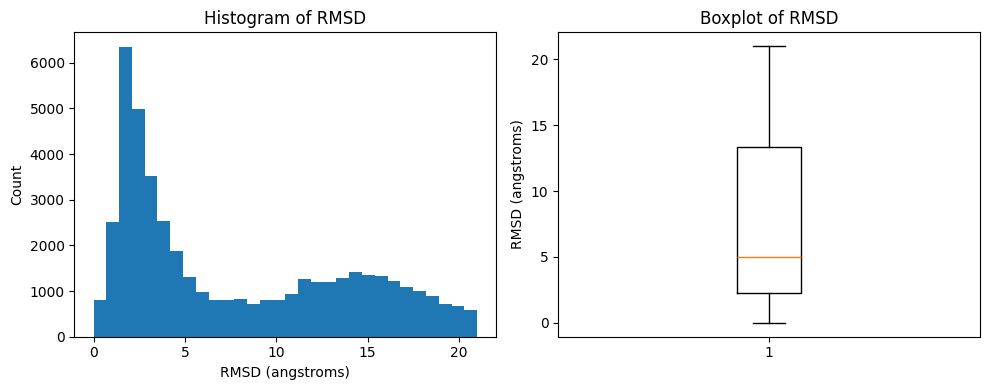

In [ ]:
# ============================================================
# 1.3 Univariate Analysis
# ------------------------------------------------------------
# Univariate analysis means looking at one variable at a time.
# I start with the target variable RMSD to understand how
# protein structure errors are distributed.
# ============================================================

# Create a figure with two plots side by side
plt.figure(figsize=(10,4))

# Histogram of RMSD
plt.subplot(1,2,1)
plt.hist(df["RMSD"], bins=30)
plt.title("Histogram of RMSD")
plt.xlabel("RMSD (angstroms)")
plt.ylabel("Count")

# Boxplot of RMSD
plt.subplot(1,2,2)
plt.boxplot(df["RMSD"])
plt.title("Boxplot of RMSD")
plt.ylabel("RMSD (angstroms)")

plt.tight_layout()
plt.show()


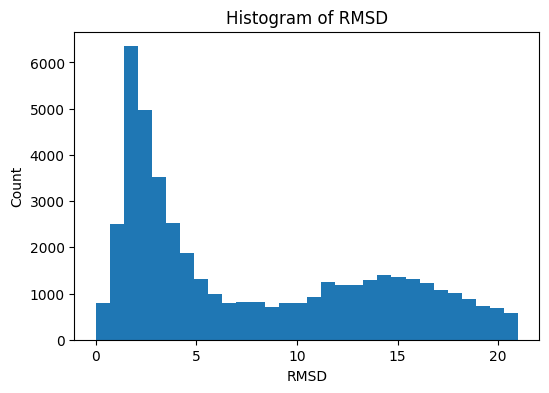

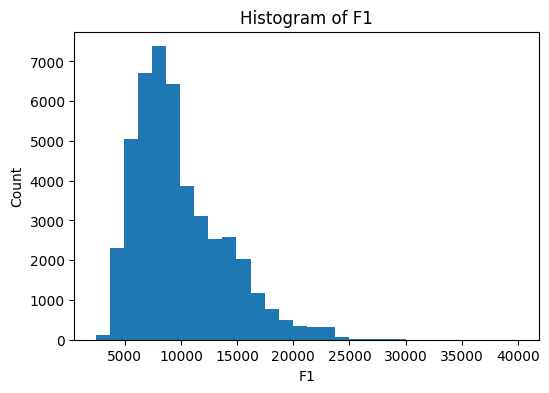

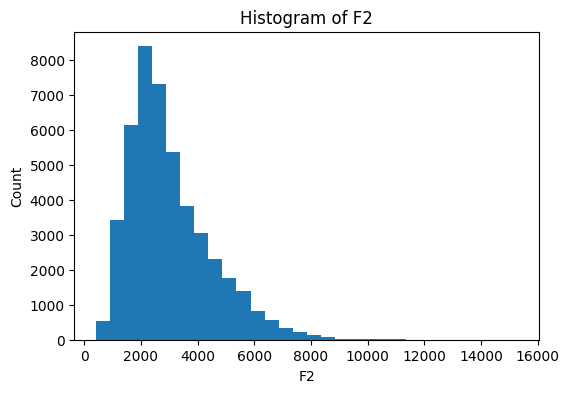

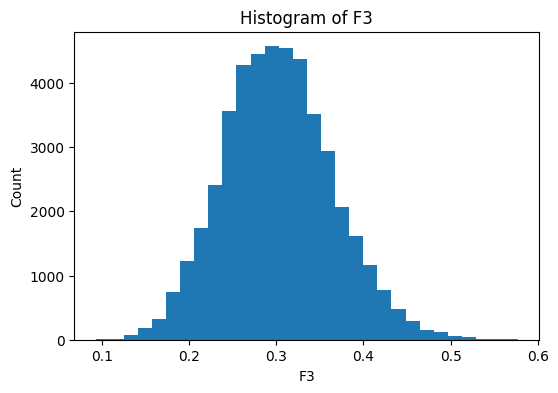

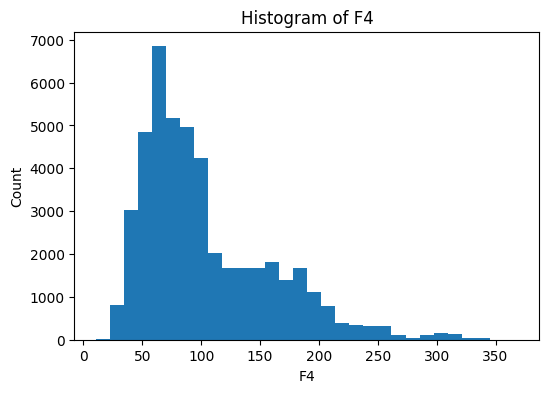

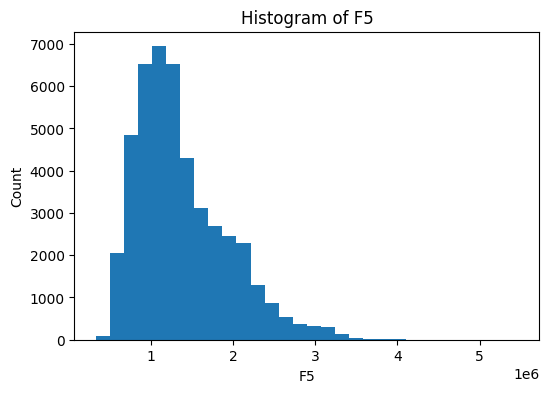

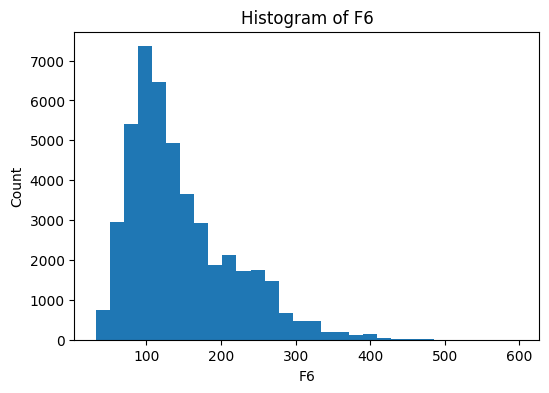

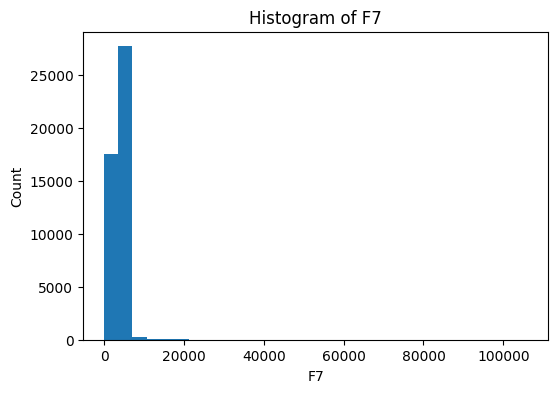

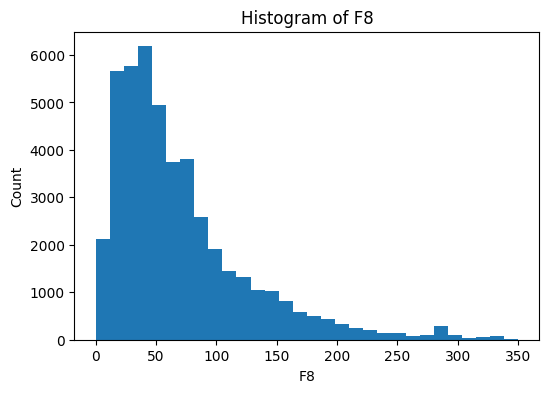

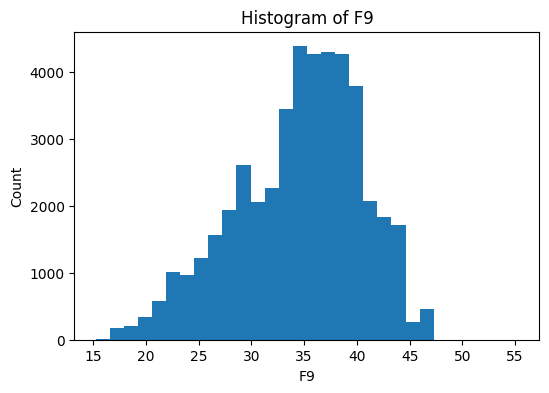

In [ ]:
# ------------------------------------------------------------
# Univariate analysis for feature variables (F1 to F9)
# ------------------------------------------------------------
# I plot a histogram for each feature to understand its
# distribution, skewness, and possible outliers.
# ------------------------------------------------------------

for col in df.columns:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


In [ ]:
# ============================================================
# 1.4 Bivariate Analysis
# ------------------------------------------------------------
# Bivariate analysis means comparing two variables at once.
# Here, I calculate correlations to see how each feature
# is related to the target variable RMSD.
# ============================================================

# Compute correlation matrix
correlation_matrix = df.corr()

# Display full correlation matrix
correlation_matrix


,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
RMSD,1.000000,-0.015087,0.156895,0.374309,-0.169771,-0.013982,-0.036135,-0.003339,0.000344,0.062830
F1,-0.015087,1.000000,0.906606,0.126285,0.931056,0.998185,0.967531,0.554002,0.651251,-0.898240
F2,0.156895,0.906606,1.000000,0.502562,0.793143,0.902853,0.908354,0.515929,0.584242,-0.786188
F3,0.374309,0.126285,0.502562,1.000000,0.031230,0.122622,0.200650,0.080064,0.095340,-0.069039
F4,-0.169771,0.931056,0.793143,0.031230,1.000000,0.925707,0.938108,0.485185,0.676919,-0.891766
F5,-0.013982,0.998185,0.902853,0.122622,0.925707,1.000000,0.961769,0.553729,0.642961,-0.897765
F6,-0.036135,0.967531,0.908354,0.200650,0.938108,0.961769,1.000000,0.538198,0.662584,-0.881973
F7,-0.003339,0.554002,0.515929,0.080064,0.485185,0.553729,0.538198,1.000000,0.347030,-0.521148
F8,0.000344,0.651251,0.584242,0.095340,0.676919,0.642961,0.662584,0.347030,1.000000,-0.637287
F9,0.062830,-0.898240,-0.786188,-0.069039,-0.891766,-0.897765,-0.881973,-0.521148,-0.637287,1.000000


In [ ]:
# ------------------------------------------------------------
# Correlation values specifically with RMSD
# ------------------------------------------------------------
# This helps me quickly identify which features have a stronger
# relationship with protein structure error.
# ------------------------------------------------------------

correlation_matrix["RMSD"].sort_values(ascending=False)


,RMSD
RMSD,1.000000
F3,0.374309
F2,0.156895
F9,0.062830
F8,0.000344
F7,-0.003339
F5,-0.013982
F1,-0.015087
F6,-0.036135
F4,-0.169771


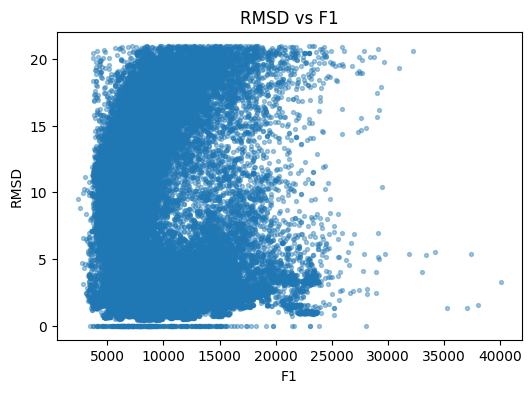

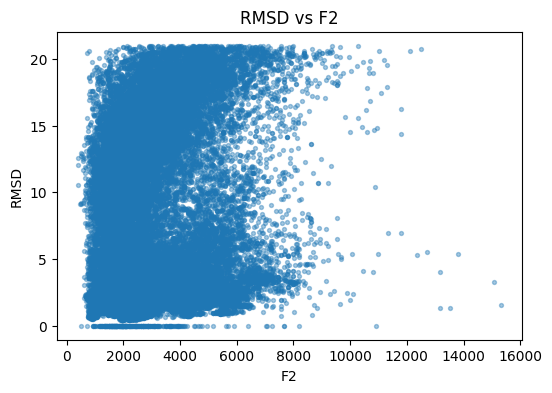

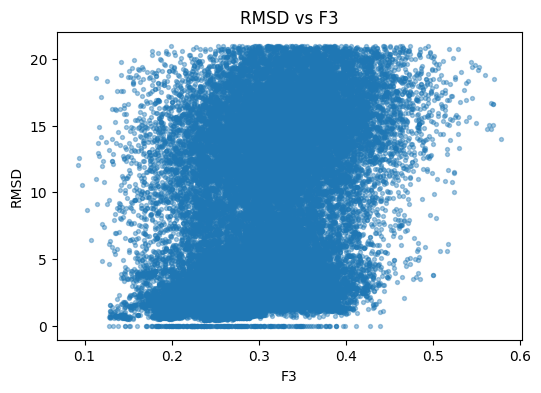

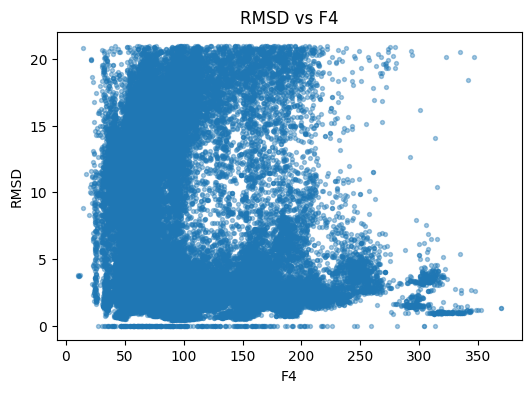

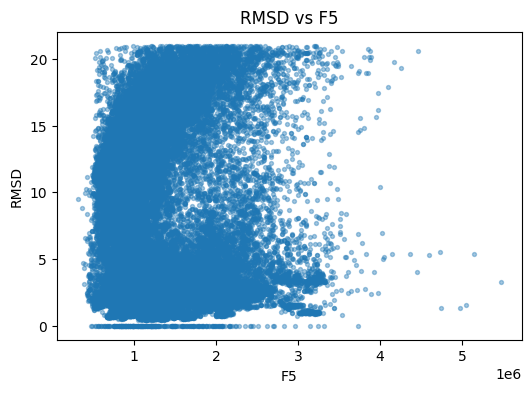

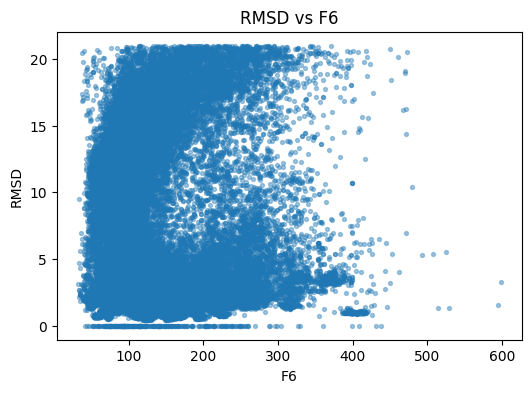

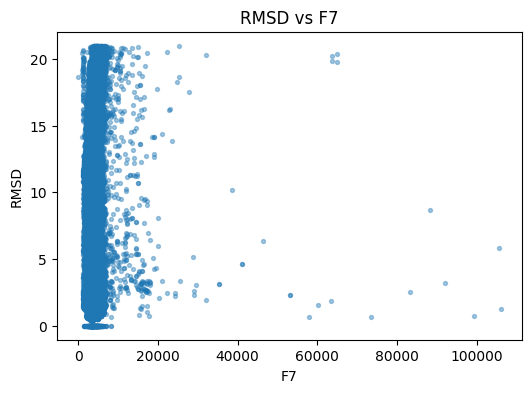

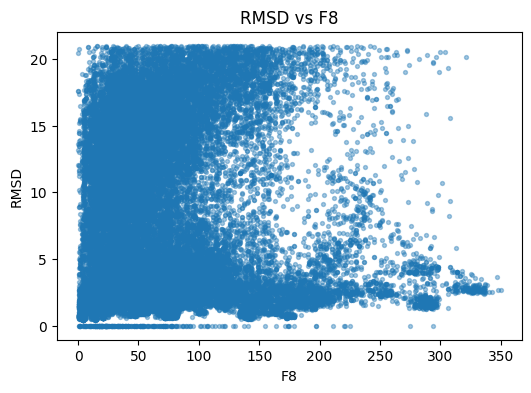

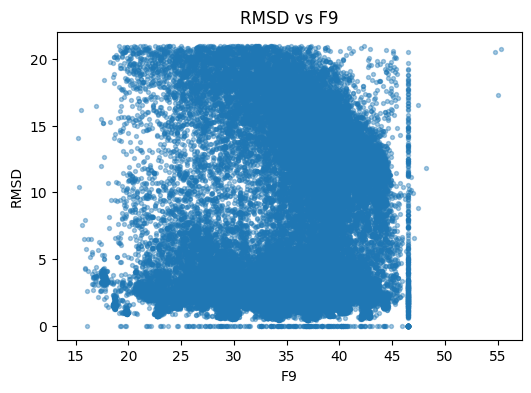

In [ ]:
# ------------------------------------------------------------
# Scatter plots: RMSD vs each feature
# ------------------------------------------------------------
# Scatter plots allow me to visually inspect relationships
# between RMSD and individual features.
# ------------------------------------------------------------

for col in features:
    plt.figure()
    plt.scatter(df[col], df["RMSD"], alpha=0.4, s=8)
    plt.title(f"RMSD vs {col}")
    plt.xlabel(col)
    plt.ylabel("RMSD")
    plt.show()


## Section 2: Data Cleaning, Pre-processing, and Feature Engineering


In [ ]:
# ============================================================
# 2.1 Overview
# ------------------------------------------------------------
# In this step, I reconfirm that the dataset is loaded correctly
# and review its structure before starting any cleaning or
# preprocessing. This is similar to double-checking ingredients
# before cooking.
# ============================================================

# Display basic information again for reference
print("Dataset shape (rows, columns):", df.shape)
df.info()


Dataset shape (rows, columns): (45730, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45730 entries, 0 to 45729
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RMSD    45730 non-null  float64
 1   F1      45730 non-null  float64
 2   F2      45730 non-null  float64
 3   F3      45730 non-null  float64
 4   F4      45730 non-null  float64
 5   F5      45730 non-null  float64
 6   F6      45730 non-null  float64
 7   F7      45730 non-null  float64
 8   F8      45730 non-null  int64  
 9   F9      45730 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 3.5 MB


In [ ]:
# ============================================================
# 2.2 Missing Values Analysis
# ------------------------------------------------------------
# Missing values can cause machine learning models to fail or
# behave incorrectly. Here, I check if any column contains
# missing (NaN) values.
# ============================================================

# Count missing values per column
missing_values = df.isnull().sum()
missing_values


,0
RMSD,0
F1,0
F2,0
F3,0
F4,0
F5,0
F6,0
F7,0
F8,0
F9,0


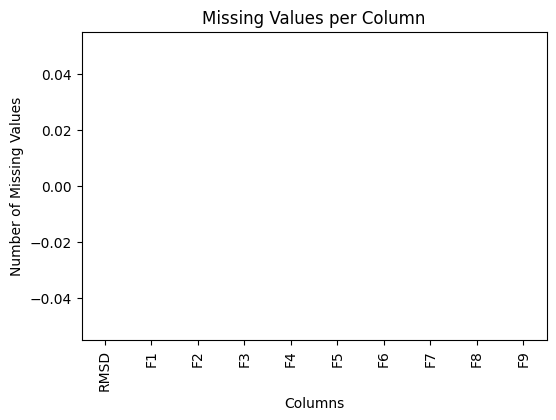

In [ ]:
# ------------------------------------------------------------
# Visual confirmation of missing values
# ------------------------------------------------------------
# This bar plot helps me visually confirm whether missing
# values exist in the dataset.
# ------------------------------------------------------------

missing_values.plot(kind="bar")
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()


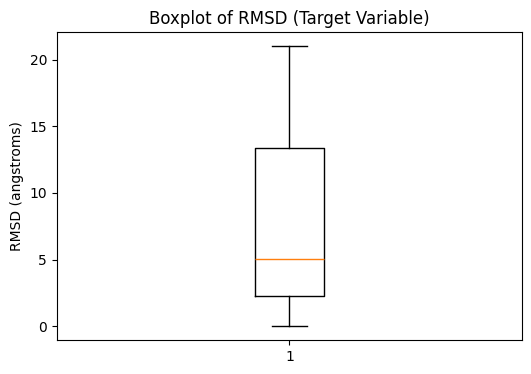

In [ ]:
# ============================================================
# 2.3 Outlier Detection - Target Variable (RMSD)
# ------------------------------------------------------------
# I use a boxplot to visually inspect outliers in the target
# variable RMSD. Boxplots are a simple way to spot unusually
# large or small values.
# ============================================================

plt.figure()
plt.boxplot(df["RMSD"])
plt.title("Boxplot of RMSD (Target Variable)")
plt.ylabel("RMSD (angstroms)")
plt.show()


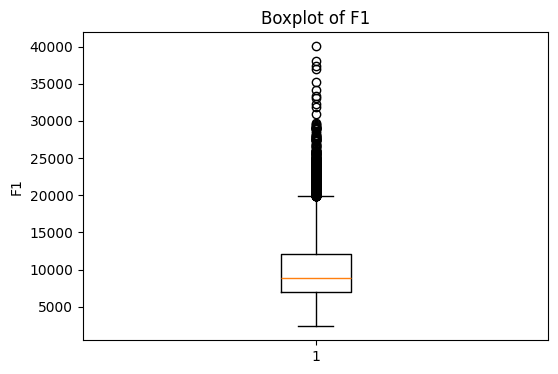

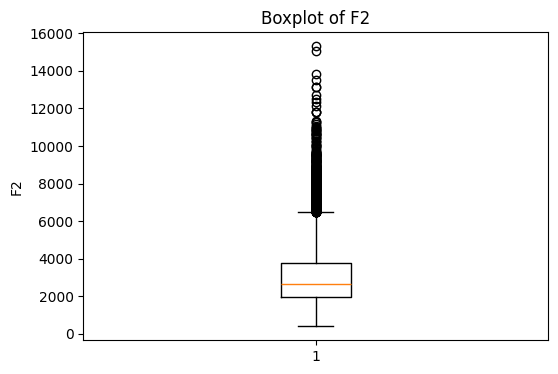

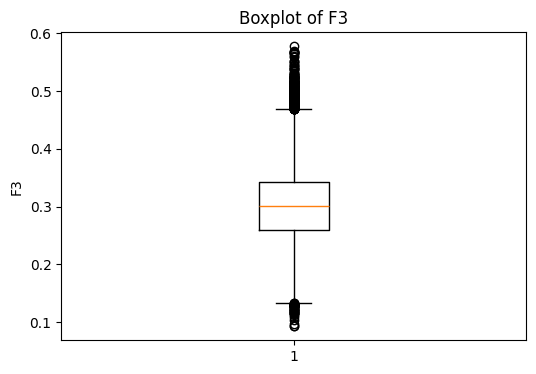

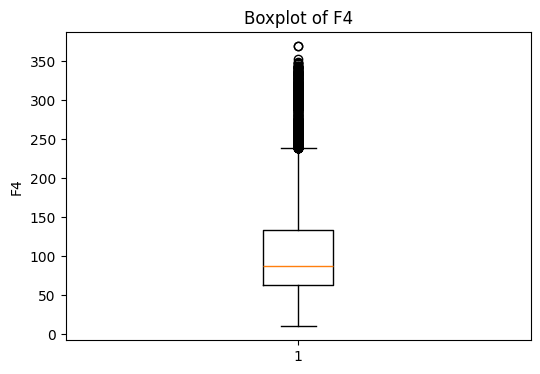

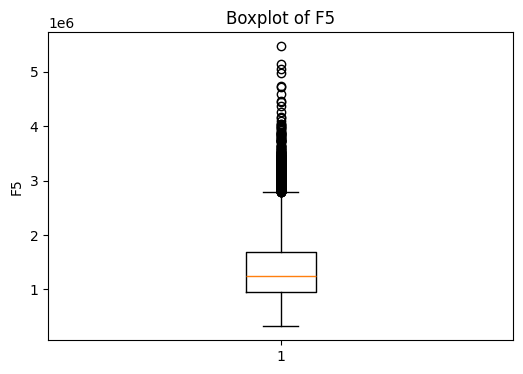

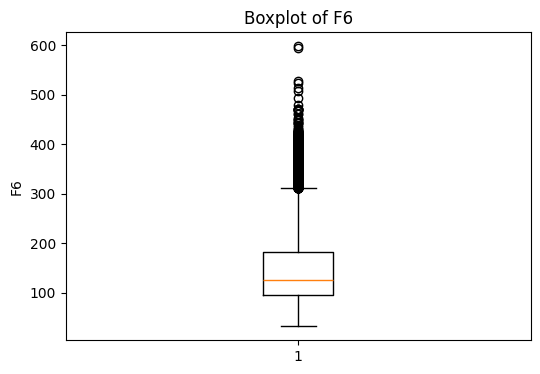

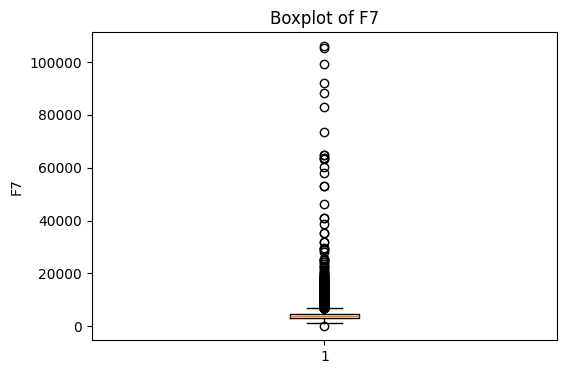

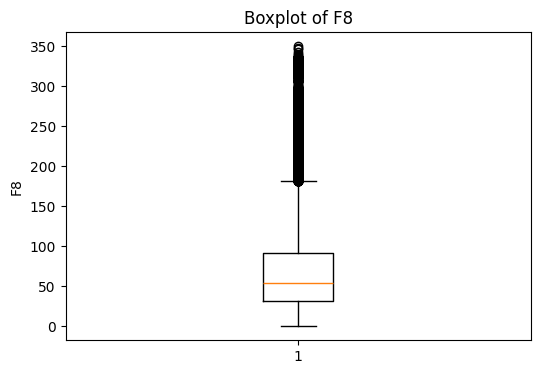

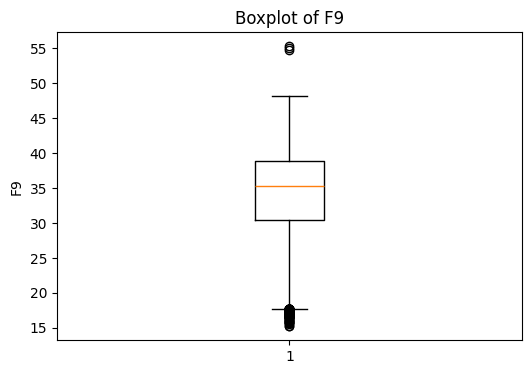

In [ ]:
# ------------------------------------------------------------
# Outlier detection for feature variables (F1–F9)
# ------------------------------------------------------------
# I loop through each feature and create a boxplot to see
# whether extreme values exist.
# ------------------------------------------------------------

for col in features:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()


In [ ]:
# ============================================================
# 2.4 Decision on Handling Outliers
# ------------------------------------------------------------
# Based on visual inspection, I observe outliers in several
# features. However, these values represent rare but valid
# protein structures, not data errors.
#
# Therefore, I do NOT remove any rows.
# Instead, I handle outliers using feature scaling in the
# next step.
# ============================================================

print("Decision: Keep all data points and handle outliers using scaling.")


Decision: Keep all data points and handle outliers using scaling.


In [ ]:
# ============================================================
# 2.5 Feature Pre-processing: Standard Scaling
# ------------------------------------------------------------
# The feature values have very different ranges. Some are
# smaller than 1, while others reach into the millions.
#
# To ensure fair contribution of all features, I apply
# standard scaling (mean = 0, standard deviation = 1).
# ============================================================

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Apply scaling to feature variables only
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Display first few rows after scaling
X_scaled_df.head()


,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,0.908481,0.879584,0.240885,1.058750,0.894440,0.996035,0.149539,0.566885,-1.253153
1,-0.906740,-0.952127,-0.640245,-0.903989,-1.001457,-0.834813,-0.331492,-0.548301,0.672800
2,-0.528725,-0.881704,-1.255652,-0.653210,-0.518857,-0.912117,-0.505989,-0.725315,0.717134
3,-0.356576,-0.443293,-0.338425,-0.643398,-0.279821,-0.517141,-0.371967,0.000441,0.759477
4,-0.594061,-0.874424,-1.106651,-0.921619,-0.615710,-0.730225,-0.589569,-0.512898,0.901558


In [ ]:
# ------------------------------------------------------------
# Verifying scaling results
# ------------------------------------------------------------
# After standard scaling:
# - Each feature should have a mean close to 0
# - Each feature should have a standard deviation close to 1
# ------------------------------------------------------------

X_scaled_df.describe()


,F1,F2,F3,F4,F5,F6,F7,F8,F9
count,4.573000e+04,4.573000e+04,4.573000e+04,4.573000e+04,4.573000e+04,4.573000e+04,4.573000e+04,4.573000e+04,4.573000e+04
mean,8.235024e-17,2.125568e-16,-2.257640e-16,-1.532025e-16,-7.271682e-17,2.986362e-16,-1.149019e-16,-5.344997e-17,-5.835991e-16
std,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00
min,-1.843118e+00,-1.785052e+00,-3.337702e+00,-1.681252e+00,-1.859489e+00,-1.623859e+00,-2.001330e+00,-1.238654e+00,-3.226867e+00
25%,-7.232255e-01,-7.090870e-01,-6.941525e-01,-7.204146e-01,-7.352577e-01,-7.268811e-01,-4.135499e-01,-6.899119e-01,-6.854768e-01
50%,-2.397165e-01,-2.384826e-01,-3.565041e-02,-2.842004e-01,-2.323987e-01,-2.780355e-01,-7.503488e-02,-2.827805e-01,1.297118e-01
75%,5.555695e-01,5.251918e-01,6.440013e-01,5.440623e-01,5.719920e-01,5.118746e-01,3.282765e-01,3.721699e-01,7.269836e-01
max,7.432875e+00,8.396203e+00,4.377792e+00,4.796167e+00,7.275692e+00,6.468284e+00,5.114408e+01,4.956823e+00,3.474634e+00


In [ ]:
# ============================================================
# 2.6 Feature Engineering Decisions
# ------------------------------------------------------------
# Based on exploratory analysis:
# - All features (F1–F9) are numeric and meaningful
# - No redundant or irrelevant features were identified
#
# Therefore:
# - I keep all original features
# - I do not create new engineered features at this stage
# ============================================================

print("Features retained for modeling:")
print(features)


Features retained for modeling:
['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9']


## Section 3: Data Modelling and Data Splitting


In [ ]:
# ============================================================
# 3.1 Framing the Prediction Task as Classification
# ------------------------------------------------------------
# The original target RMSD is a continuous value. To turn this
# into a classification problem, I create quality categories.
#
# Example scheme (you can adjust thresholds if needed):
# - Class 0: "Good" structure (RMSD <= 2.0)
# - Class 1: "Acceptable" structure (2.0 < RMSD <= 5.0)
# - Class 2: "Poor" structure (RMSD > 5.0)
#
# This is similar to turning exact exam scores into letter
# grades like A, B, C.
# ============================================================

# Define a function to map RMSD values to classes
def rmsd_to_class(rmsd_value):
    if rmsd_value <= 2.0:
        return 0   # Good
    elif rmsd_value <= 5.0:
        return 1   # Acceptable
    else:
        return 2   # Poor

# Apply the function to create a new target column
df["RMSD_class"] = df["RMSD"].apply(rmsd_to_class)

# Look at the first few rows to confirm
df[["RMSD", "RMSD_class"]].head()


,RMSD,RMSD_class
0,17.284,2
1,6.021,2
2,9.275,2
3,15.851,2
4,7.962,2


Class counts (0=Good, 1=Acceptable, 2=Poor):
RMSD_class
0     8677
1    14128
2    22925
Name: count, dtype: int64


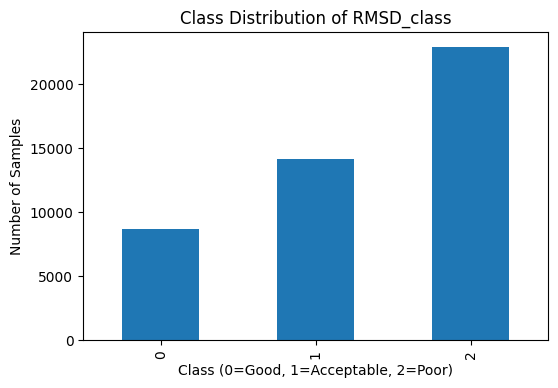

In [ ]:
# ============================================================
# 3.2 Inspect Class Distribution
# ------------------------------------------------------------
# Before splitting the data, I check how many examples belong
# to each class. This helps me understand whether the classes
# are balanced or imbalanced.
# ============================================================

class_counts = df["RMSD_class"].value_counts().sort_index()
print("Class counts (0=Good, 1=Acceptable, 2=Poor):")
print(class_counts)

# Plot the distribution as a bar chart
class_counts.plot(kind="bar")
plt.title("Class Distribution of RMSD_class")
plt.xlabel("Class (0=Good, 1=Acceptable, 2=Poor)")
plt.ylabel("Number of Samples")
plt.show()


In [ ]:
# ============================================================
# 3.3 Define Features and Classification Target
# ------------------------------------------------------------
# For modeling:
# - X will be the scaled features (from Section 2)
# - y_class will be the RMSD-based class labels
#
# I use the standardized feature DataFrame (X_scaled_df) that
# I created earlier to ensure all features are on a similar
# scale for modeling.
# ============================================================

# X: scaled features (F1–F9)
X_for_model = X_scaled_df.copy()

# y: class labels based on RMSD
y_class = df["RMSD_class"]

print("Features shape:", X_for_model.shape)
print("Target shape:", y_class.shape)


Features shape: (45730, 9)
Target shape: (45730,)


In [ ]:
# ============================================================
# 3.4 Train/Test Split (with Stratification)
# ------------------------------------------------------------
# I split the data into:
# - 80% training set (for learning patterns)
# - 20% test set (for final evaluation)
#
# I use stratified sampling so that the class distribution
# (0, 1, 2) is similar in both the train and test sets.
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_for_model,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class  # keeps class proportions similar
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 36584
Test set size: 9146


In [ ]:
# ============================================================
# 3.5 Verify Class Distribution After Splitting
# ------------------------------------------------------------
# Here I check that stratification worked correctly by
# comparing the class distributions in the training and
# test sets. They should be similar to the original.
# ============================================================

# Original distribution
print("Original class distribution:")
print(y_class.value_counts(normalize=True).sort_index())

print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True).sort_index())


Original class distribution:
RMSD_class
0    0.189744
1    0.308944
2    0.501312
Name: proportion, dtype: float64

Training set class distribution:
RMSD_class
0    0.189755
1    0.308933
2    0.501312
Name: proportion, dtype: float64

Test set class distribution:
RMSD_class
0    0.189700
1    0.308988
2    0.501312
Name: proportion, dtype: float64


## Section 4: Model Selection

In [ ]:
# ============================================================
# 4.1 Importing Classification Models
# ------------------------------------------------------------
# In this step, I import the four classification models that I
# decided to use in the PDF:
# - Logistic Regression
# - K-Nearest Neighbors (KNN)
# - Decision Tree
# - Random Forest
#
# These models will be used later for training, evaluation,
# and comparison.
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# ============================================================
# 4.2 Defining the Four Classification Models
# ------------------------------------------------------------
# Here I create one instance of each model with reasonable
# default settings. These settings will later be adjusted
# (tuned) in Section 5, but for now they act as initial
# configurations.
# ============================================================

# 1. Logistic Regression
# max_iter is increased to make sure the algorithm converges.
log_reg_clf = LogisticRegression(max_iter=1000, random_state=42)

# 2. K-Nearest Neighbors
# k=5 is a common starting choice.
knn_clf = KNeighborsClassifier(n_neighbors=5)

# 3. Decision Tree
# random_state is set for reproducible results.
dt_clf = DecisionTreeClassifier(random_state=42)

# 4. Random Forest
# 100 trees is a standard default for a starting point.
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)


In [ ]:
# ============================================================
# 4.3 Organizing Models in a Dictionary
# ------------------------------------------------------------
# To make it easier to loop over models later (for training,
# evaluation, and comparison), I store them in a Python
# dictionary with human-readable names.
# ============================================================

models = {
    "Logistic Regression": log_reg_clf,
    "K-Nearest Neighbors": knn_clf,
    "Decision Tree": dt_clf,
    "Random Forest": rf_clf
}

# Show the keys to confirm that the models are registered
print("Models defined for classification:")
for name in models.keys():
    print("-", name)


Models defined for classification:
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest


In [ ]:
# ============================================================
# 4.4 Simple Summary Table of the Selected Models
# ------------------------------------------------------------
# This small table matches what I wrote in the PDF:
# it reminds me which models I chose and what their main
# idea is, in simple words.
# ============================================================

import pandas as pd

model_summary = pd.DataFrame({
    "Model Name": [
        "Logistic Regression",
        "K-Nearest Neighbors (KNN)",
        "Decision Tree",
        "Random Forest"
    ],
    "Main Idea (Short)": [
        "Learns a linear boundary between classes.",
        "Looks at the k closest neighbors to classify.",
        "Asks a series of if/else questions (tree).",
        "Combines many decision trees (ensemble)."
    ]
})

model_summary


,Model Name,Main Idea (Short)
0,Logistic Regression,Learns a linear boundary between classes.
1,K-Nearest Neighbors (KNN),Looks at the k closest neighbors to classify.
2,Decision Tree,Asks a series of if/else questions (tree).
3,Random Forest,Combines many decision trees (ensemble).


## Section 5: Model Training, Hyperparameter Tuning, and Model Building


In [ ]:
# ============================================================
# 5.1 Imports for Model Training and Evaluation
# ------------------------------------------------------------
# In this step, I import tools for:
# - cross-validation
# - hyperparameter tuning
# - accuracy calculation
# - measuring training time
# ============================================================

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score
import time
import pandas as pd


In [ ]:
# ============================================================
# 5.2 Baseline Training (Before Hyperparameter Tuning)
# ------------------------------------------------------------
# Here I train each of the four models with their initial
# (default) settings. I measure:
# - training time
# - training accuracy
# - test accuracy
#
# These results will act as a baseline to compare against
# the tuned models later.
# ============================================================

baseline_results = []

for name, model in models.items():
    print(f"\n==================== {name} ====================")

    # Measure training time
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time

    # Training accuracy
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Test accuracy
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"Training accuracy (baseline): {train_acc:.4f}")
    print(f"Test accuracy (baseline): {test_acc:.4f}")
    print(f"Training time (seconds): {training_time:.4f}")

    baseline_results.append({
        "Model": name,
        "Train Accuracy (Baseline)": train_acc,
        "Test Accuracy (Baseline)": test_acc,
        "Train Time (Baseline)": training_time
    })

baseline_df = pd.DataFrame(baseline_results)
baseline_df



==================== Logistic Regression ====================
Training accuracy (baseline): 0.5965
Test accuracy (baseline): 0.5935
Training time (seconds): 2.4853

==================== K-Nearest Neighbors ====================
Training accuracy (baseline): 0.8597
Test accuracy (baseline): 0.7953
Training time (seconds): 0.1597

==================== Decision Tree ====================
Training accuracy (baseline): 0.9997
Test accuracy (baseline): 0.7579
Training time (seconds): 0.8952

==================== Random Forest ====================
Training accuracy (baseline): 0.9997
Test accuracy (baseline): 0.8446
Training time (seconds): 20.8829


,Model,Train Accuracy (Baseline),Test Accuracy (Baseline),Train Time (Baseline)
0,Logistic Regression,0.596518,0.593483,2.485277
1,K-Nearest Neighbors,0.859747,0.795320,0.159712
2,Decision Tree,0.999699,0.757927,0.895170
3,Random Forest,0.999699,0.844632,20.882911


In [ ]:
# ============================================================
# Recreate Model Definitions (Section 4 Rebuild)
# ------------------------------------------------------------
# This ensures the 'models' dictionary exists before training.
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Define models again
log_reg_clf = LogisticRegression(max_iter=1000, random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=5)
dt_clf = DecisionTreeClassifier(random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Store them in a dictionary
models = {
    "Logistic Regression": log_reg_clf,
    "K-Nearest Neighbors": knn_clf,
    "Decision Tree": dt_clf,
    "Random Forest": rf_clf
}

print("Models successfully recreated.")


Models successfully recreated.


In [ ]:
# ============================================================
# 5.2 (Rebuild) - Baseline Training for All Models
# ------------------------------------------------------------
# This cell (re)computes the baseline results so that
# 'baseline_df' exists and can be used in later steps.
# ============================================================

from sklearn.metrics import accuracy_score
import time
import pandas as pd

baseline_results = []

for name, model in models.items():
    print(f"\n==================== {name} (Baseline) ====================")

    # Measure training time
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time

    # Training accuracy
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Test accuracy
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"Training accuracy (baseline): {train_acc:.4f}")
    print(f"Test accuracy (baseline): {test_acc:.4f}")
    print(f"Training time (seconds): {training_time:.4f}")

    baseline_results.append({
        "Model": name,
        "Train Accuracy (Baseline)": train_acc,
        "Test Accuracy (Baseline)": test_acc,
        "Train Time (Baseline)": training_time
    })

# Convert list of dicts to DataFrame
baseline_df = pd.DataFrame(baseline_results)

# Show baseline results
baseline_df



==================== Logistic Regression (Baseline) ====================
Training accuracy (baseline): 0.5965
Test accuracy (baseline): 0.5935
Training time (seconds): 3.0049

==================== K-Nearest Neighbors (Baseline) ====================
Training accuracy (baseline): 0.8597
Test accuracy (baseline): 0.7953
Training time (seconds): 0.1385

==================== Decision Tree (Baseline) ====================
Training accuracy (baseline): 0.9997
Test accuracy (baseline): 0.7579
Training time (seconds): 0.8909

==================== Random Forest (Baseline) ====================
Training accuracy (baseline): 0.9997
Test accuracy (baseline): 0.8446
Training time (seconds): 21.6423


,Model,Train Accuracy (Baseline),Test Accuracy (Baseline),Train Time (Baseline)
0,Logistic Regression,0.596518,0.593483,3.004907
1,K-Nearest Neighbors,0.859747,0.795320,0.138528
2,Decision Tree,0.999699,0.757927,0.890900
3,Random Forest,0.999699,0.844632,21.642326


In [ ]:
# ============================================================
# 5.3 Cross-Validation for Baseline Models
# ------------------------------------------------------------
# To get a more reliable estimate of performance, I run
# k-fold cross-validation (k=5) on the training set for
# each model. This helps me see how stable each model is.
# ============================================================

cv_results = []

for name, model in models.items():
    print(f"\nCross-validation for {name}")

    # 5-fold cross-validation on the training set
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    print("CV scores:", cv_scores)
    print("Mean CV accuracy:", cv_scores.mean())

    cv_results.append({
        "Model": name,
        "CV Mean Accuracy (Baseline)": cv_scores.mean()
    })

cv_df = pd.DataFrame(cv_results)
cv_df



Cross-validation for Logistic Regression
CV scores: [0.59450595 0.59177258 0.60038267 0.60065601 0.59226353]
Mean CV accuracy: 0.5959161476980179

Cross-validation for K-Nearest Neighbors
CV scores: [0.79117125 0.78679787 0.78597786 0.7862512  0.78198469]
Mean CV accuracy: 0.786436571947276

Cross-validation for Decision Tree
CV scores: [0.76083094 0.75563756 0.75440754 0.74825748 0.75574084]
Mean CV accuracy: 0.7549748733317477

Cross-validation for Random Forest
CV scores: [0.84201175 0.83791171 0.84392511 0.8396884  0.83966648]
Mean CV accuracy: 0.8406406906241468


,Model,CV Mean Accuracy (Baseline)
0,Logistic Regression,0.595916
1,K-Nearest Neighbors,0.786437
2,Decision Tree,0.754975
3,Random Forest,0.840641


In [ ]:
# ============================================================
# 5.4 Hyperparameter Grids
# ------------------------------------------------------------
# I keep the grids small so that GridSearchCV can finish
# in a reasonable time, while still demonstrating proper
# hyperparameter tuning for all four models.
# ============================================================

param_grids = {
    "Logistic Regression": {
        "C": [0.1, 1],          # smaller range, still meaningful
        "penalty": ["l2"],
        "solver": ["lbfgs"]
    },
    "K-Nearest Neighbors": {
        "n_neighbors": [3, 7],  # fewer options than [3,5,7,9]
        "weights": ["uniform", "distance"]
    },
    "Decision Tree": {
        "max_depth": [None, 10],     # shallow vs deep
        "min_samples_split": [2, 10] # less combinations
    },
    "Random Forest": {
        "n_estimators": [50, 100],   # fewer forests
        "max_depth": [None, 10],
        "max_features": ["sqrt"]     # single strategy
    }
}

param_grids


{'Logistic Regression': {'C': [0.1, 1],
  'penalty': ['l2'],
  'solver': ['lbfgs']},
 'K-Nearest Neighbors': {'n_neighbors': [3, 7],
  'weights': ['uniform', 'distance']},
 'Decision Tree': {'max_depth': [None, 10], 'min_samples_split': [2, 10]},
 'Random Forest': {'n_estimators': [50, 100],
  'max_depth': [None, 10],
  'max_features': ['sqrt']}}

In [ ]:
# ============================================================
# 5.5 Hyperparameter Tuning with GridSearchCV
# ------------------------------------------------------------
# I reduce:
# - the number of parameter combinations
# - the number of CV folds (cv=3 instead of 5)
#
# This still demonstrates proper tuning and cross-validation,
# but finishes faster on this dataset.
# ============================================================

from sklearn.model_selection import GridSearchCV

tuned_models = {}
tuning_results = []

for name, model in models.items():
    print(f"\n==================== Tuning {name} ====================")

    param_grid = param_grids[name]

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=3,               # fewer folds than 5 to speed up
        scoring='accuracy',
        n_jobs=-1           # use all available cores
    )

    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()
    tuning_time = end_time - start_time

    best_model = grid_search.best_estimator_
    tuned_models[name] = best_model

    print("Best parameters:", grid_search.best_params_)
    print("Best CV accuracy:", grid_search.best_score_)
    print("Tuning time (seconds):", tuning_time)

    tuning_results.append({
        "Model": name,
        "Best CV Accuracy (Tuned)": grid_search.best_score_,
        "Tuning Time": tuning_time,
        "Best Params": grid_search.best_params_
    })

tuning_df = pd.DataFrame(tuning_results)
tuning_df



==================== Tuning Logistic Regression ====================
Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.5958342341610503
Tuning time (seconds): 10.86238408088684

==================== Tuning K-Nearest Neighbors ====================
Best parameters: {'n_neighbors': 7, 'weights': 'distance'}
Best CV accuracy: 0.8006231138797091
Tuning time (seconds): 15.115978479385376

==================== Tuning Decision Tree ====================
Best parameters: {'max_depth': None, 'min_samples_split': 2}
Best CV accuracy: 0.7427563980959366
Tuning time (seconds): 11.055048942565918

==================== Tuning Random Forest ====================
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV accuracy: 0.8329324591151986
Tuning time (seconds): 105.3638265132904


,Model,Best CV Accuracy (Tuned),Tuning Time,Best Params
0,Logistic Regression,0.595834,10.862384,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}"
1,K-Nearest Neighbors,0.800623,15.115978,"{'n_neighbors': 7, 'weights': 'distance'}"
2,Decision Tree,0.742756,11.055049,"{'max_depth': None, 'min_samples_split': 2}"
3,Random Forest,0.832932,105.363827,"{'max_depth': None, 'max_features': 'sqrt', 'n..."


In [ ]:
# ============================================================
# 5.6 Evaluation of Tuned Models
# ------------------------------------------------------------
# Now I evaluate the tuned models on:
# - training set (to check fit)
# - test set (to see generalization)
#
# This allows me to compare baseline vs tuned versions.
# ============================================================

tuned_eval_results = []

for name, model in tuned_models.items():
    print(f"\n==================== {name} (Tuned) ====================")

    # Training accuracy
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Test accuracy
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"Training accuracy (tuned): {train_acc:.4f}")
    print(f"Test accuracy (tuned): {test_acc:.4f}")

    tuned_eval_results.append({
        "Model": name,
        "Train Accuracy (Tuned)": train_acc,
        "Test Accuracy (Tuned)": test_acc
    })

tuned_eval_df = pd.DataFrame(tuned_eval_results)
tuned_eval_df



==================== Logistic Regression (Tuned) ====================
Training accuracy (tuned): 0.5965
Test accuracy (tuned): 0.5935

==================== K-Nearest Neighbors (Tuned) ====================
Training accuracy (tuned): 0.9997
Test accuracy (tuned): 0.8158

==================== Decision Tree (Tuned) ====================
Training accuracy (tuned): 0.9997
Test accuracy (tuned): 0.7579

==================== Random Forest (Tuned) ====================
Training accuracy (tuned): 0.9997
Test accuracy (tuned): 0.8446


,Model,Train Accuracy (Tuned),Test Accuracy (Tuned)
0,Logistic Regression,0.596518,0.593483
1,K-Nearest Neighbors,0.999699,0.815766
2,Decision Tree,0.999699,0.757927
3,Random Forest,0.999699,0.844632


In [ ]:
# ============================================================
# 5.7 Comparison: Baseline vs Tuned Models
# ------------------------------------------------------------
# This cell combines all results from previous steps into
# one final comparison table.
# ============================================================

# Safety check: make sure required variables exist
for var_name in ["baseline_df", "cv_df", "tuning_df", "tuned_eval_df"]:
    if var_name not in globals():
        raise NameError(f"{var_name} is not defined. Please run previous Section 5 cells first.")

# Merge baseline & CV (baseline)
combined = baseline_df.merge(cv_df, on="Model", how="left")

# Merge tuning results (CV tuned + time + best params)
combined = combined.merge(
    tuning_df[["Model", "Best CV Accuracy (Tuned)", "Tuning Time", "Best Params"]],
    on="Model",
    how="left"
)

# Merge tuned evaluation (train/test after tuning)
combined = combined.merge(tuned_eval_df, on="Model", how="left")

# Reorder columns for readability
combined = combined[
    [
        "Model",
        "Train Accuracy (Baseline)",
        "Test Accuracy (Baseline)",
        "CV Mean Accuracy (Baseline)",
        "Best CV Accuracy (Tuned)",
        "Train Accuracy (Tuned)",
        "Test Accuracy (Tuned)",
        "Train Time (Baseline)",
        "Tuning Time",
        "Best Params",
    ]
]

# Display final comparison table
combined


,Model,Train Accuracy (Baseline),Test Accuracy (Baseline),CV Mean Accuracy (Baseline),Best CV Accuracy (Tuned),Train Accuracy (Tuned),Test Accuracy (Tuned),Train Time (Baseline),Tuning Time,Best Params
0,Logistic Regression,0.596518,0.593483,0.595916,0.595834,0.596518,0.593483,3.004907,10.862384,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}"
1,K-Nearest Neighbors,0.859747,0.795320,0.786437,0.800623,0.999699,0.815766,0.138528,15.115978,"{'n_neighbors': 7, 'weights': 'distance'}"
2,Decision Tree,0.999699,0.757927,0.754975,0.742756,0.999699,0.757927,0.890900,11.055049,"{'max_depth': None, 'min_samples_split': 2}"
3,Random Forest,0.999699,0.844632,0.840641,0.832932,0.999699,0.844632,21.642326,105.363827,"{'max_depth': None, 'max_features': 'sqrt', 'n..."


## Section 6: Model Performance Metrics and Improvement


In [ ]:
# ============================================================
# 6.1 Import Required Metrics and Plotting Tools
# ------------------------------------------------------------
# Here I import:
# - evaluation metrics to measure model performance
# - libraries to create plots and tables
# ============================================================

# Accuracy, confusion matrix, and detailed classification report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Libraries for plotting graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Pandas is used to store results in tables
import pandas as pd


In [ ]:
# ============================================================
# 6.2 Test Accuracy of Tuned Models
# ------------------------------------------------------------
# In this step, I:
# - use each tuned model to make predictions on the test set
# - compare predictions with true labels
# - compute accuracy for each model
# ============================================================

# Create an empty list to store results
test_accuracy_results = []

# Loop through each tuned model
for name, model in tuned_models.items():

    # Use the trained model to predict class labels for test data
    y_pred = model.predict(X_test)

    # Calculate accuracy by comparing predictions with true labels
    acc = accuracy_score(y_test, y_pred)

    # Store the model name and accuracy in a dictionary
    test_accuracy_results.append({
        "Model": name,
        "Test Accuracy": acc
    })

# Convert results into a DataFrame for better readability
accuracy_df = pd.DataFrame(test_accuracy_results)

# Display the accuracy table
accuracy_df


,Model,Test Accuracy
0,Logistic Regression,0.593483
1,K-Nearest Neighbors,0.815766
2,Decision Tree,0.757927
3,Random Forest,0.844632


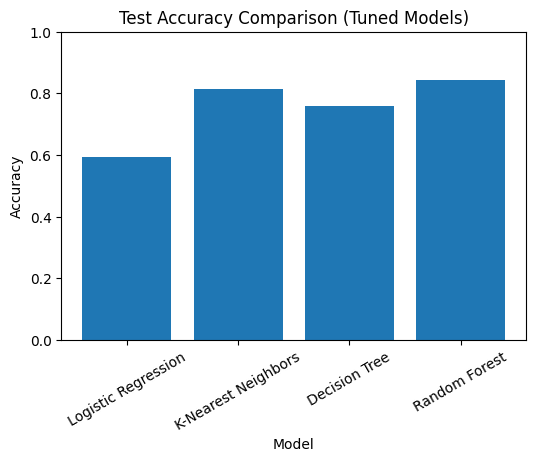

In [ ]:
# ============================================================
# 6.3 Bar Chart: Test Accuracy Comparison
# ------------------------------------------------------------
# This visualization helps me quickly compare how accurate
# each tuned model is on the test dataset.
# ============================================================

# Create a bar plot
plt.figure()

# X-axis: model names, Y-axis: accuracy values
plt.bar(accuracy_df["Model"], accuracy_df["Test Accuracy"])

# Limit Y-axis between 0 and 1 since accuracy is a percentage
plt.ylim(0, 1)

# Add title and axis labels
plt.title("Test Accuracy Comparison (Tuned Models)")
plt.ylabel("Accuracy")
plt.xlabel("Model")

# Rotate model names to avoid overlap
plt.xticks(rotation=30)

# Display the plot
plt.show()


In [ ]:
# ============================================================
# 6.4 Classification Reports
# ------------------------------------------------------------
# The classification report shows:
# - Precision: how reliable predictions are
# - Recall: how many actual cases are detected
# - F1-score: balance between precision and recall
#
# This is useful for understanding performance per class.
# ============================================================

# Loop through each tuned model
for name, model in tuned_models.items():

    print(f"\n================ {name} =================")

    # Predict class labels on the test data
    y_pred = model.predict(X_test)

    # Print detailed classification report
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Good", "Acceptable", "Poor"]
        )
    )



================ Logistic Regression =================
              precision    recall  f1-score   support

        Good       0.50      0.21      0.30      1735
  Acceptable       0.50      0.38      0.43      2826
        Poor       0.64      0.87      0.73      4585

    accuracy                           0.59      9146
   macro avg       0.55      0.49      0.49      9146
weighted avg       0.57      0.59      0.56      9146


================ K-Nearest Neighbors =================
              precision    recall  f1-score   support

        Good       0.76      0.82      0.79      1735
  Acceptable       0.73      0.76      0.75      2826
        Poor       0.90      0.85      0.87      4585

    accuracy                           0.82      9146
   macro avg       0.80      0.81      0.80      9146
weighted avg       0.82      0.82      0.82      9146


================ Decision Tree =================
              precision    recall  f1-score   support

        Good       0.

In [ ]:
# ============================================================
# 6.5 Accuracy Before vs After Hyperparameter Tuning
# ------------------------------------------------------------
# This table shows whether tuning actually improved
# test accuracy for each model.
# ============================================================

# Select only relevant columns from the combined results
comparison_df = combined[[
    "Model",
    "Test Accuracy (Baseline)",
    "Test Accuracy (Tuned)"
]]

# Display comparison table
comparison_df


,Model,Test Accuracy (Baseline),Test Accuracy (Tuned)
0,Logistic Regression,0.593483,0.593483
1,K-Nearest Neighbors,0.795320,0.815766
2,Decision Tree,0.757927,0.757927
3,Random Forest,0.844632,0.844632


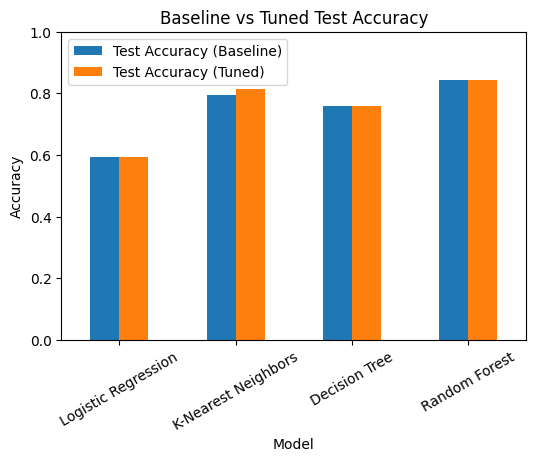

In [ ]:
# ============================================================
# 6.6 Visualization: Baseline vs Tuned Accuracy
# ------------------------------------------------------------
# This grouped bar chart visually shows the improvement
# achieved after hyperparameter tuning.
# ============================================================

# Set model names as index for cleaner plotting
comparison_df.set_index("Model").plot(
    kind="bar",
    ylim=(0, 1),
    title="Baseline vs Tuned Test Accuracy"
)

# Add axis labels
plt.ylabel("Accuracy")
plt.xlabel("Model")

# Rotate labels for readability
plt.xticks(rotation=30)

# Display the plot
plt.show()


## Section 7: Results Visualization and Discussion (Colab)


In [ ]:
# ============================================================
# 7.1 Imports and Setup
# ------------------------------------------------------------
# In this cell, I import all the libraries needed for
# visualizing and evaluating the model results.
# ============================================================

# NumPy is used for numerical operations
import numpy as np

# Pandas is used to create and display tables
import pandas as pd

# Matplotlib is used for basic plotting
import matplotlib.pyplot as plt

# Seaborn is used for nicer-looking plots like heatmaps
import seaborn as sns

# Import evaluation metrics from scikit-learn
from sklearn.metrics import (
    accuracy_score,        # to measure overall correctness
    classification_report, # to get precision, recall, F1-score
    confusion_matrix,      # to see prediction errors per class
    f1_score,              # to compute F1-score explicitly
    roc_curve,             # to compute ROC curve values
    auc                    # to compute Area Under Curve
)

# Used to convert multiclass labels into binary format for ROC
from sklearn.preprocessing import label_binarize


In [ ]:
# ============================================================
# 7.2 Summary Metrics: Accuracy and Macro F1-Score
# ------------------------------------------------------------
# Here I calculate two important metrics for each tuned model:
# 1. Test Accuracy  -> how often predictions are correct
# 2. Macro F1-score -> average F1-score across all classes
# ============================================================

# Create an empty list to store results for each model
summary_results = []

# Loop through each tuned model stored in the dictionary
for name, model in tuned_models.items():

    # Use the trained model to predict class labels on test data
    y_pred = model.predict(X_test)

    # Calculate test accuracy by comparing predictions to true labels
    acc = accuracy_score(y_test, y_pred)

    # Calculate macro F1-score (treats all classes equally)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    # Store the results in a dictionary
    summary_results.append({
        "Model": name,
        "Test Accuracy": acc,
        "Macro F1-Score": macro_f1
    })

# Convert the list of results into a DataFrame
summary_df = pd.DataFrame(summary_results)

# Display the summary table
summary_df


,Model,Test Accuracy,Macro F1-Score
0,Logistic Regression,0.593483,0.489518
1,K-Nearest Neighbors,0.815766,0.802039
2,Decision Tree,0.757927,0.741322
3,Random Forest,0.844632,0.829099


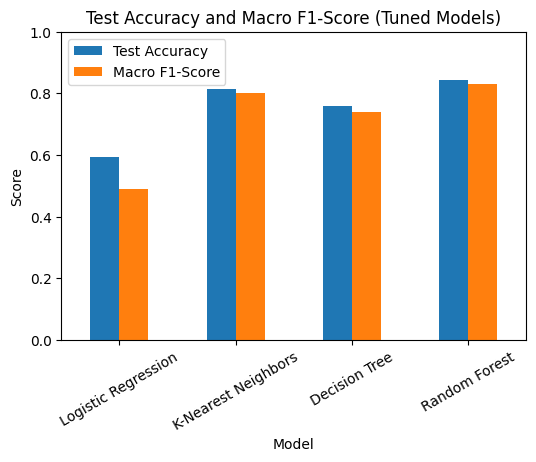

In [ ]:
# ============================================================
# 7.3 Visualization: Accuracy vs Macro F1-Score
# ------------------------------------------------------------
# This plot helps me compare:
# - how accurate each model is overall
# - how balanced the model is across all classes
# ============================================================

# Set the model names as the index to make plotting easier
plot_df = summary_df.set_index("Model")

# Create a bar plot with both metrics
plot_df.plot(
    kind="bar",   # bar chart
    ylim=(0, 1),  # metric values range from 0 to 1
    rot=30        # rotate x-axis labels for readability
)

# Add plot title
plt.title("Test Accuracy and Macro F1-Score (Tuned Models)")

# Label y-axis
plt.ylabel("Score")

# Label x-axis
plt.xlabel("Model")

# Display the plot
plt.show()


In [ ]:
# ============================================================
# 7.4 Per-Class F1-Score Heatmap
# ------------------------------------------------------------
# In this step, I compute F1-score for each class separately
# and visualize the results using a heatmap.
#
# Rows   -> models
# Columns-> classes (Good, Acceptable, Poor)
# ============================================================

# Define class names for readability
classes = ["Good", "Acceptable", "Poor"]

# Define numeric class labels used in the dataset
class_indices = [0, 1, 2]

# Create an empty dictionary to store F1-scores
per_class_f1 = {}

# Loop through each tuned model
for name, model in tuned_models.items():

    # Predict class labels on test data
    y_pred = model.predict(X_test)

    # Create a list to store F1-score for each class
    f1_scores = []

    # Loop through each class label
    for cls in class_indices:
        # Compute F1-score for the current class
        f1_cls = f1_score(
            y_test,
            y_pred,
            labels=[cls],
            average='macro'
        )
        f1_scores.append(f1_cls)

    # Store the F1-scores for this model
    per_class_f1[name] = f1_scores

# Convert dictionary to DataFrame
# Rows = models, Columns = classes
f1_df = pd.DataFrame(per_class_f1, index=classes).T

# Display the table
f1_df


,Good,Acceptable,Poor
Logistic Regression,0.301049,0.433006,0.734498
K-Nearest Neighbors,0.787576,0.746792,0.871749
Decision Tree,0.721813,0.679945,0.822207
Random Forest,0.819503,0.772984,0.894809


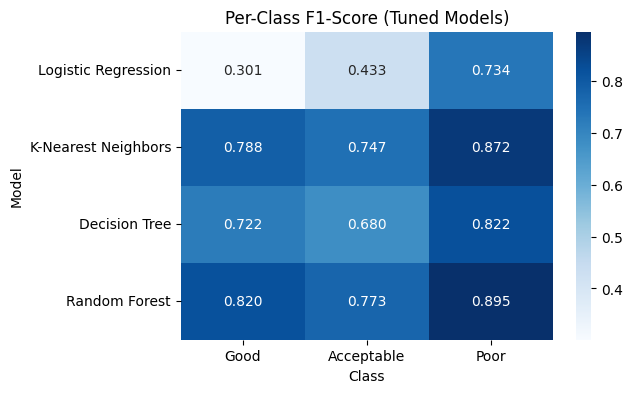

In [ ]:
# Plot heatmap for per-class F1-scores
plt.figure(figsize=(6,4))

# Create heatmap with values shown inside cells
sns.heatmap(
    f1_df,
    annot=True,     # show numbers
    fmt=".3f",      # format numbers to 3 decimals
    cmap="Blues"    # color theme
)

# Add title and axis labels
plt.title("Per-Class F1-Score (Tuned Models)")
plt.xlabel("Class")
plt.ylabel("Model")

# Display heatmap
plt.show()


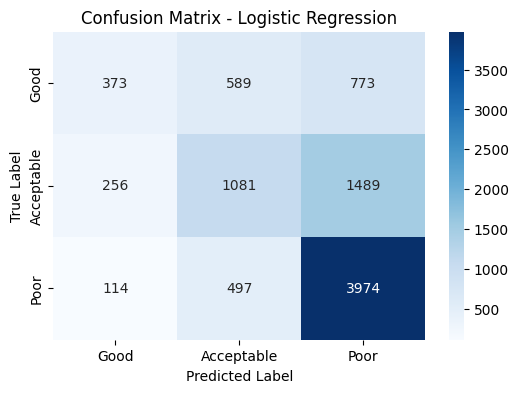

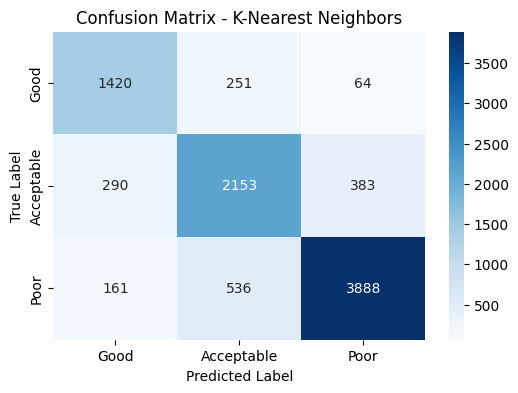

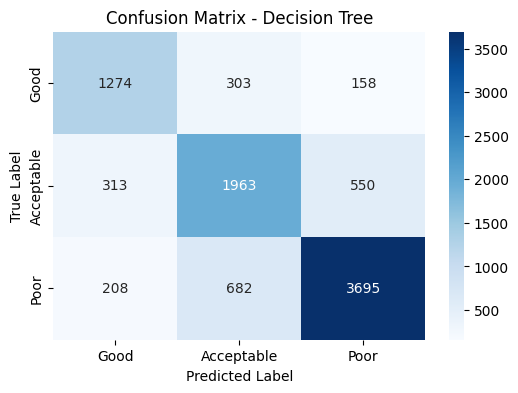

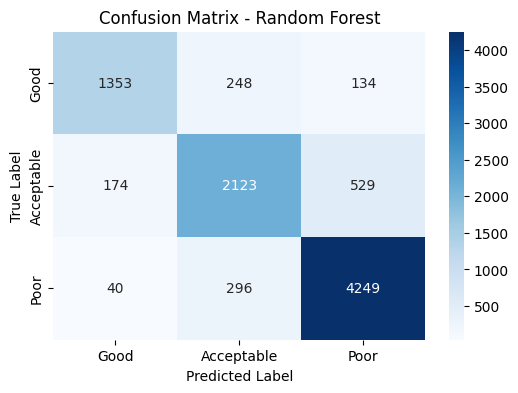

In [ ]:
# ============================================================
# 7.5 Confusion Matrices
# ------------------------------------------------------------
# Confusion matrices show:
# - how many predictions are correct
# - which classes are confused with each other
#
# Rows    -> actual class
# Columns -> predicted class
# ============================================================

# Loop through each tuned model
for name, model in tuned_models.items():

    # Predict class labels for the test set
    y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Create a new figure for each model
    plt.figure()

    # Plot confusion matrix as a heatmap
    sns.heatmap(
        cm,
        annot=True,        # show numbers in cells
        fmt="d",           # integer format
        cmap="Blues",      # color theme
        xticklabels=["Good", "Acceptable", "Poor"],
        yticklabels=["Good", "Acceptable", "Poor"]
    )

    # Add title and axis labels
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    # Display the plot
    plt.show()


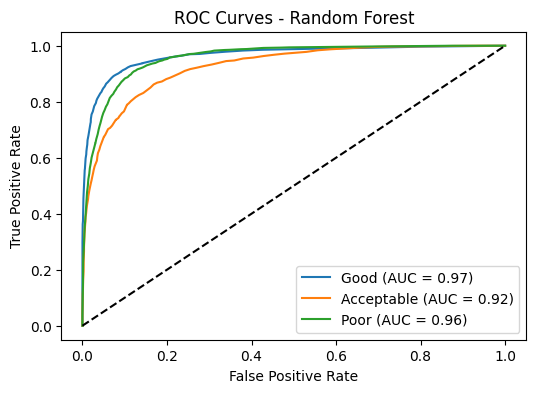

In [ ]:
# ============================================================
# 7.6 ROC Curves for the Best Model (Random Forest)
# ------------------------------------------------------------
# ROC curves show how well the model separates each class
# from the others using predicted probabilities.
#
# Since this is a multiclass problem, I use a one-vs-rest
# approach.
# ============================================================

# Select Random Forest as the best-performing model
best_model_name = "Random Forest"
best_model = tuned_models[best_model_name]

# Predict probabilities for each class
y_score = best_model.predict_proba(X_test)

# Convert true class labels into binary format
# This is required for multiclass ROC computation
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Number of classes
n_classes = y_test_binarized.shape[1]

# Create dictionaries to store ROC values
fpr = {}       # false positive rate
tpr = {}       # true positive rate
roc_auc = {}   # area under curve

# Compute ROC curve and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(
        y_test_binarized[:, i],
        y_score[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(6,4))

# Plot one ROC curve per class
for i, class_name in enumerate(["Good", "Acceptable", "Poor"]):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_name} (AUC = {roc_auc[i]:.2f})"
    )

# Plot diagonal line representing random guessing
plt.plot([0, 1], [0, 1], "k--")

# Add labels and title
plt.title("ROC Curves - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# Display plot
plt.show()
